In [1]:
import pickle
import numpy as np
import pandas as pd


with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/droite_active_epochs.pkl", "rb") as f:
    droite_active = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/droite_repos_epochs.pkl", "rb") as f:
    droite_repos = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/gauche_active_epochs.pkl", "rb") as f:
    gauche_active = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/gauche_repos_epochs.pkl", "rb") as f:
    gauche_repos = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/avancer_active_epochs.pkl", "rb") as f:
    avancer_active = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/avancer_repos_epochs.pkl", "rb") as f:
    avancer_repos = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/reculer_active_epochs.pkl", "rb") as f:
    reculer_active = pickle.load(f)
with open("/home/colin/Python-Projects/Projet EEG/EEG-Intentions/data/Notebook 1/reculer_repos_epochs.pkl", "rb") as f:
    reculer_repos = pickle.load(f)


In [2]:
droite_active[0].head()

,Sample Index,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,Timestamp,Status
1275,35.0,-2170.262074,-2207.174887,-2056.735541,-1889.608762,1.749061e+09,active
1276,35.0,-2168.414564,-2204.489639,-2054.985268,-1842.901151,1.749061e+09,None
1277,36.0,-2166.409977,-2205.095503,-2052.546853,-1912.343614,1.749061e+09,None
1278,36.0,-2169.446776,-2207.818150,-2053.833379,-1880.838697,1.749061e+09,None
1279,37.0,-2173.867338,-2206.688700,-2052.232702,-1881.388462,1.749061e+09,None


In [3]:
import numpy as np
import pandas as pd
from numpy.fft import fft, fftfreq

def features_engineering(epochs, label, fs=200):
    bandes = {
        "Delta": (0.5, 4),
        "Theta": (4, 7.5),
        "Alpha": (8, 13),
        "Mu": (7, 13),
        "Beta": (14, 26),
        "Gamma_lent": (30, 70),
        "Gamma_rapide": (70, fs/2),
    }

    lignes = []

    for i, epoch in enumerate(epochs):
        exg_cols = [c for c in epoch.columns if str(c).strip().startswith("EXG")]
        EXG = epoch.loc[:, exg_cols].copy()
        EXG.columns = [c.strip() for c in EXG.columns]

        N = len(EXG)
        freqs = fftfreq(N, 1/fs)
        mask_util = ((freqs > 0.5) & (freqs <= 100) & ~((freqs >= 59) & (freqs <= 61)))
        freqs_utiles = freqs[mask_util]

        for channel in EXG.columns:
            x = EXG[channel].to_numpy(dtype=float)

            # Stats temporelles
            mean_val = float(np.mean(x))
            std_val  = float(np.std(x))
            var_val  = float(np.var(x))
            ptp_val  = float(np.ptp(x))

            # FFT
            Y = fft(x)
            P = np.abs(Y)**2
            P_utiles = P[mask_util]

            row = {
                "Epoch": int(i),
                "Label": str(label),
                "Canal": str(channel),
                "mean": mean_val,
                "std": std_val,
                "var": var_val,
                "ptp": ptp_val,
            }

            for nom, (fmin, fmax) in bandes.items():
                if freqs_utiles.size:
                    m = (freqs_utiles >= fmin) & (freqs_utiles <= fmax)
                    p = float(np.trapezoid(P_utiles[m], freqs_utiles[m])) if np.any(m) else 0.0
                else:
                    p = 0.0
                row[f"Power_{nom}"] = p

            lignes.append(row)

    df = pd.DataFrame(lignes)

    # Vérif finale: aucune colonne object qui cache des tableaux
    # (hors Label/Canal qui sont des strings)
    num_cols = [c for c in df.columns if c not in ("Label", "Canal")]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

    return df


In [4]:
df_feat_droite = features_engineering(droite_active, label='droite_active')
df_feat_gauche = features_engineering(gauche_active, label='gauche_active')
df_feat_avancer = features_engineering(avancer_active, label='avancer_active')
df_feat_reculer = features_engineering(reculer_active, label='reculer_active')

df_feat_droite_repos = features_engineering(droite_repos, label='droite_repos')
df_feat_gauche_repos = features_engineering(gauche_repos, label='gauche_repos')
df_feat_avancer_repos = features_engineering(avancer_repos, label='avancer_repos')
df_feat_reculer_repos = features_engineering(reculer_repos, label='reculer_repos')



In [5]:
df_droite_all = pd.concat([df_feat_droite, df_feat_droite_repos], ignore_index=True)

df_droite_all['Label'] = df_droite_all["Label"].replace({
    "droite_active": 1,
    "droite_repos": 0
})

df_droite_all = df_droite_all.drop(labels=['Epoch', 'Canal'], axis=1)

for col in df_droite_all.columns:
    df_droite_all[col] = pd.to_numeric(df_droite_all[col], errors="coerce")

/tmp/ipykernel_129910/899636115.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_droite_all['Label'] = df_droite_all["Label"].replace({


In [6]:
df_droite_all.head()

,Label,mean,std,var,ptp,Power_Delta,Power_Theta,Power_Alpha,Power_Mu,Power_Beta,Power_Gamma_lent,Power_Gamma_rapide
0,1,-2173.469735,32.842130,1078.605501,321.414482,1.140781e+08,3.526936e+06,714538.113001,8.763445e+05,9.673989e+05,1.529713e+06,6.734396e+05
1,1,-2205.183482,30.963364,958.729923,299.934367,1.034896e+08,3.184291e+06,658682.828300,9.006079e+05,6.605978e+05,9.585412e+05,6.239353e+05
2,1,-2063.379691,7.648335,58.497021,52.861616,5.346257e+06,7.701955e+05,667828.723360,1.094881e+06,1.222575e+06,8.900374e+05,5.142223e+05
3,1,-1891.350566,9.637444,92.880324,102.989365,5.075843e+06,6.257330e+05,569348.185942,8.272880e+05,1.121756e+06,5.436498e+06,4.525040e+06
4,1,-2179.250322,15.465621,239.185422,102.213336,1.153154e+07,7.057480e+05,490322.912846,6.202761e+05,6.676512e+05,8.314520e+05,5.021501e+05


In [7]:
import sklearn
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Chargement du dataset
y = df_droite_all['Label']
X = df_droite_all.drop(labels='Label', axis=1)

# Chargement des données
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Création d'un modèle
classifier = DecisionTreeClassifier(max_depth=2, random_state=42)

# Fit du modèle
classifier.fit(train_X, train_y)

# Prédiction
pred_y = classifier.predict(test_X)

# Evaluation
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [8]:
print(df_droite_all["Label"].dtype)

int64


# Analyse
Le modèle semble bien prédire si le patient est en train de penser à droite ou est au repos à 100% trop beau pour être vrai?  C'est tout de même bon signe

## Logistic Regression
on va tenter une Logistic Regression avec droite, gauche, avancer, reculer

In [9]:
df_all = pd.concat([df_feat_droite, df_feat_gauche, df_feat_reculer, df_feat_avancer], ignore_index=True)
df_all = df_all.drop(labels=['Epoch', 'Canal'], axis=1)



df_all['Label'] = df_all["Label"].replace({
    "droite_active": 0,
    "gauche_active": 1,
    "avancer_active": 2,
    "reculer_active": 3,
})

for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")





print(df_all["Label"].unique())


[0 1 3 2]


/tmp/ipykernel_129910/809701681.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all['Label'] = df_all["Label"].replace({


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Chargement du dataset
y = df_all['Label']
X = df_all.drop(labels='Label', axis=1)

# Chargement des données
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Création d'un modèle
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

# Fit du modèle
pipe.fit(train_X, train_y)

# Prédiction
pred_y = pipe.predict(test_X)

# Evaluation
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

           0       0.50      0.07      0.12        14
           1       0.37      0.70      0.48        10
           2       0.33      0.30      0.32        10
           3       0.67      0.86      0.75        14

    accuracy                           0.48        48
   macro avg       0.47      0.48      0.42        48
weighted avg       0.49      0.48      0.42        48



# Analyse
- droite = 0
- gauche = 1
- avancer = 2
- reculer = 3

Le modèle présente une précision de 48%, ce qui n’est pas excellent en soi, mais reste tout de même un progrès.

Le modèle semble bien détecter l’intention **gauche** avec un recall de 70% et **reculer** avec 86%.

En revanche, il ne détecte pas bien **droite** (7%) et **avancer** (30%), peut-être à cause d’un bruit trop important.

Le F1-score de la classe 3 domine avec 75 %, ce qui peut biaiser la précision globale.

## Pistes possibles pour augmenter la précision
- Comme vu dans le notebook 02_Analyse_fourier, les signaux sont beaucoup plus stables à partir de la seconde 4 (epoch 4) ; il faudrait donc refaire le test avec les epochs 4 à 10 et comparer les résultats.
- Refaire le test avec un nouveau jeu de données pour droite et avancer.
- RandomForest
- Ondelettes
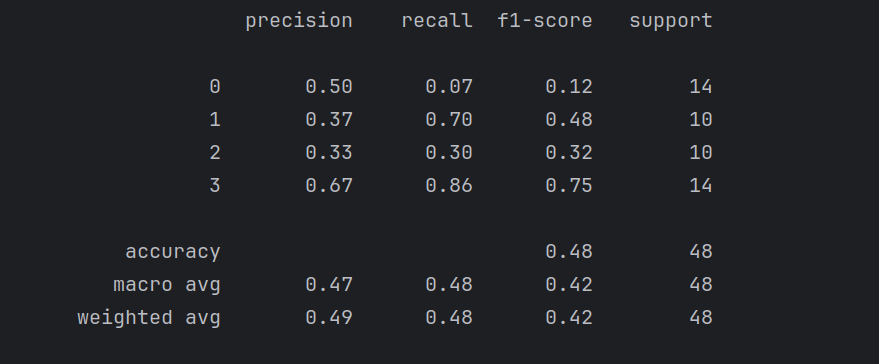
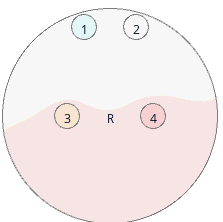